Thomas Sears

9-13-26

Block Checkpoint 1 - Spring-Mass System with Magnets

Simulation Description:

This notebook will simulate a 1-D system using the Euler-Cromer method containing a point mass with two Hookean springs on either side and two magnetic forces on each end.

For simplicity, I will assume the magnetic sources apply an attractive force on the point mass that is proportional to 1/r^2 where r is the distance between the mass and magnet and then multiplied by some strength coefficient, C.

In [3]:
import numpy as np
import matplotlib.pyplot as plt

Euler-Cromer Simulaion

In [4]:
# Physical Parameters (Measured in SI Units)
m = 1 # Mass
k = 1 # Spring Constant
C = 0.1 # Magnet Strength Coefficient
d = 3 # Distance From Center To Each Magnet

x0 = 1.0 # Initial Displacement (Measured to the right from the origin)
v0 = 0.0 # Initial Velocity
dt = 0.1 # Time Step
t_max = 50 # Must Use A Specific t_max Because Forces Are Non-Linear

def simulate(dt):
    # Initial conditions
    x = x0
    v = v0
    t = 0.0

    # Initialize Energy
    KE = 0.5 * m * v**2
    U_springs = k * x**2
    U_magnet_left = -C / (x + d)
    U_magnet_right = -C / (d - x)
    U = U_springs + U_magnet_left + U_magnet_right
    E = KE + U

    # Time, Position, Velocity, and Energy Arrays
    t_arr, x_arr, v_arr, E_arr = [t], [x], [v], [E]

    while t < t_max:

        # Calculate spring forces
        F_spring_left = -k * x
        F_spring_right = -k *x

        # Calculate magnetic forces
        F_magnet_left = -C / (x + d)**2
        F_magnet_right = C / (d - x)**2

        # Total force
        F = F_spring_left + F_spring_right + F_magnet_left + F_magnet_right

        # Acceleration
        a = F/m

        # Euler-Cromer
        v = v + a * dt
        x = x + v * dt

        t += dt

        # Update Energy
        KE = 0.5 * m * v**2
        
        U_springs = k * x**2
        
        U_magnet_left = -C / (x + d)
        U_magnet_right = -C / (d - x)
        
        U = U_springs + U_magnet_left + U_magnet_right
        
        E = KE + U

        t_arr.append(t); x_arr.append(x); v_arr.append(v); E_arr.append(E)

    return np.array(t_arr), np.array(x_arr), np.array(v_arr), np.array(E_arr)

X(t), Energy, and Phase-Space Plots

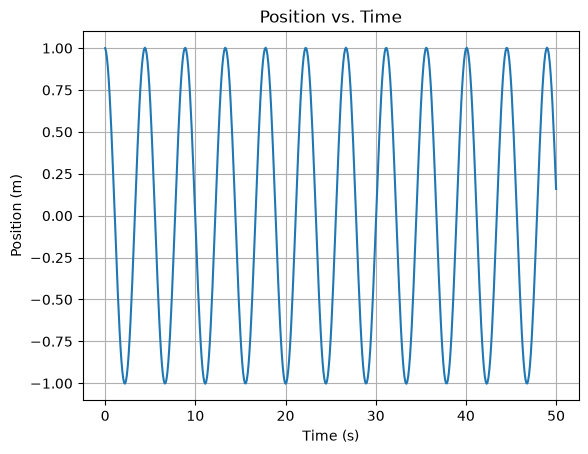

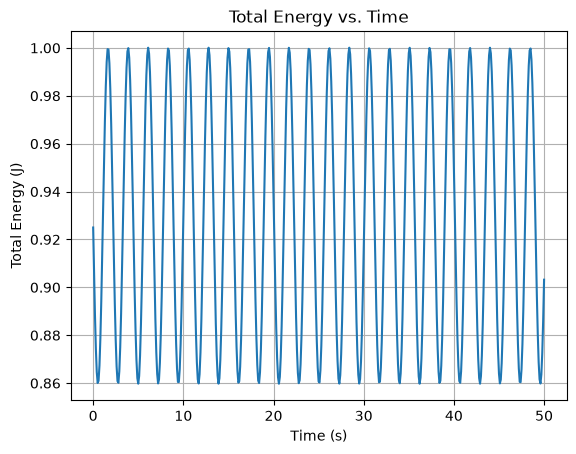

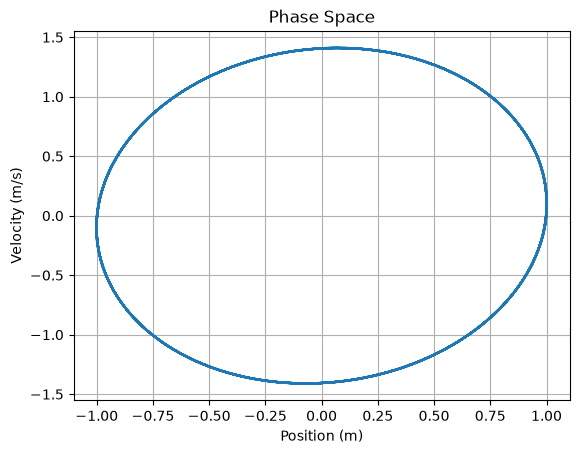

In [5]:
ts, xs, vs, Es = simulate(dt)

# Plot position vs time
plt.figure()
plt.plot(ts, xs)
plt.xlabel("Time (s)")
plt.ylabel("Position (m)")
plt.title("Position vs. Time")
plt.grid()
plt.show()

# Plot energy vs time
plt.figure()
plt.plot(ts, Es)
plt.xlabel("Time (s)")
plt.ylabel("Total Energy (J)")
plt.title("Total Energy vs. Time")
plt.grid()
plt.show()

# Plot phase space
plt.figure()
plt.plot(xs, vs)
plt.xlabel("Position (m)")
plt.ylabel("Velocity (m/s)")
plt.title("Phase Space")
plt.grid()
plt.show()